# Cross-Dataset Embedding Evaluation - ComBat Covariates


## Table of Contents

1. Notebook configuration
2. Load PREPOST
3. Helper functions
4. Shared matched-region pre/post/recon
5. Compact AHBA superset PCA
6. LORO fused full-parcel view


In [34]:
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
import numpy as np

import src.eval_utils.eval_embeddings as eval_embeddings
importlib.reload(eval_embeddings)
from src.eval_utils.eda_core import EDAConfig, prepare_pre_post_harmonization_cached
from src.eval_utils.eval_embeddings import (
    RegionEmbeddingMatrix,
    add_gtex_native_region_labels,
    add_parcel_network_labels,
    build_region_embedding_matrix_from_joint_tensor_view,
    compute_pca_embedding,
    compute_umap_embedding,
    plot_joint_embedding_sequence,
)
from src.eval_utils.eval_samples import (
    MatchingContext,
    build_combat_tensor_view,
    build_joint_tensor_view,
    build_prediction_tensor_view,
)
from src.eval_utils.eval_style import set_academic_style

set_academic_style()


## Notebook Configuration


In [35]:
# === Data/config ===
CSV_PATH = "data/raw/gxp_samples.csv"
CACHE_ROOT = 'out/loro_subject_cache_cv'
ATLAS_NETWORK_CSV = "data/metadata/atlas_info/atlas-4S156Parcels_dseg_reformatted.csv"
GENE_SCOPE = "allgenes"
MIN_OBSERVED_PARCELS = 5
COMBAT_USE_COVARIATES = True
DROP_MACRO_SYSTEM_COVARIATE = False
LORO_MODEL = "dlam"

# center | standardize | none
FEATURE_PREPROCESS = "center"

# Optional caps for fast exploratory runs. Keep None for full data.
N_GTEX_SUBJECTS = None
N_AHBA_SUBJECTS = None
ACTIVE_GENE_LIST = None
RANDOM_STATE = 0

# === PCA / UMAP controls for shared-region and compact superset sections ===
RUN_PCA = True
RUN_UMAP = True
N_PCA_FOR_UMAP = 20
UMAP_N_NEIGHBORS = 20
UMAP_MIN_DIST = 0.5
UMAP_SPREAD = 1.5
UMAP_REPULSION = 1.5
UMAP_METRIC = "cosine"
UMAP_INIT = "spectral"
UMAP_RANDOM_STATE = RANDOM_STATE

# === Plot controls ===
DATASET_MARKERS = {"GTEx": "o", "AHBA": "^"}
DATASET_POINT_SIZES = {"GTEx": 5, "AHBA": 50}
DATASET_ALPHAS = {"GTEx": 0.32, "AHBA": 0.92}
MAX_LEGEND_ITEMS = 40

# region | gtex_native_region | macro_system | region_group | age | sex | dataset | network_label | network_label_17network
SHARED_COLOR_BY = "gtex_native_region"
SUPERSET_PCA_COLOR_BY = "macro_system"
FUSED_COLOR_BY = "network_label"


## Load PREPOST


In [36]:
CFG = EDAConfig(
    csv_path=CSV_PATH,
    cache_root=CACHE_ROOT,
    gene_scope=GENE_SCOPE,
    min_observed_parcels=MIN_OBSERVED_PARCELS,
    combat_use_covariates=COMBAT_USE_COVARIATES,
    drop_macro_system_covariate=DROP_MACRO_SYSTEM_COVARIATE,
)
PREPOST = prepare_pre_post_harmonization_cached(CFG)
CTX = MatchingContext.from_cfg(CFG, PREPOST)

print(f"GTEx subjects: {len(PREPOST['subjects'])}")
print(f"Genes: {len(PREPOST['genes'])}")
print(f"Target parcels: {len(PREPOST['target_meta'])}")
print(f"Matched GTEx-AHBA parcel pairs: {len(CTX.matching)}")


[prepost_cache] hit  notebooks/cache/prepost/0f8616c23cf88e0f.pkl  (8961.2 MB)
GTEx subjects: 318
Genes: 11704
Target parcels: 150
Matched GTEx-AHBA parcel pairs: 7


## Helper Functions


In [37]:
def _combat_view(dataset, stage, region_ordering):
    n_subjects = N_GTEX_SUBJECTS if dataset == "GTEx" else N_AHBA_SUBJECTS
    return build_combat_tensor_view(
        PREPOST,
        dataset=dataset,
        stage=stage,
        cfg=CFG,
        matching_context=CTX,
        region_ordering=region_ordering,
        gene_panel=ACTIVE_GENE_LIST,
        n_subjects=n_subjects,
        random_seed=RANDOM_STATE,
    )


def _prediction_view(stage, region_ordering):
    return build_prediction_tensor_view(
        CACHE_ROOT,
        LORO_MODEL,
        dataset="GTEx",
        stage=stage,
        cfg=CFG,
        prepost=PREPOST,
        matching_context=CTX,
        region_ordering=region_ordering,
        gene_panel=ACTIVE_GENE_LIST,
        n_subjects=N_GTEX_SUBJECTS,
        random_seed=RANDOM_STATE,
    )


def _decorate_matrix(mat):
    mat = add_gtex_native_region_labels(mat, PREPOST)
    return add_parcel_network_labels(mat, ATLAS_NETWORK_CSV)


def _joint_matrix(gtex_view, ahba_view):
    joint = build_joint_tensor_view(gtex_view, ahba_view)
    mat = build_region_embedding_matrix_from_joint_tensor_view(joint)
    return _decorate_matrix(mat)


def _balance_matrix_by_dataset(mat, *, enabled=False, random_state=0):
    if not enabled:
        return mat
    counts = mat.metadata["dataset"].astype(str).value_counts()
    if len(counts) < 2:
        return mat
    n = int(counts.min())
    rng = np.random.default_rng(int(random_state))
    keep = []
    datasets = mat.metadata["dataset"].astype(str).to_numpy()
    for dataset in counts.index:
        idx = np.flatnonzero(datasets == str(dataset))
        keep.extend(rng.choice(idx, size=n, replace=False).tolist())
    keep = np.array(sorted(keep), dtype=int)
    return RegionEmbeddingMatrix(
        X=mat.X[keep],
        metadata=mat.metadata.iloc[keep].reset_index(drop=True),
        genes=list(mat.genes),
        stage=mat.stage,
        dataset=mat.dataset,
        region_axis_kind=mat.region_axis_kind,
        row_axis=mat.row_axis,
        dropped_rows=mat.dropped_rows + int(mat.X.shape[0] - keep.size),
    )


def _compute_pca_embeddings(matrices):
    return [
        compute_pca_embedding(
            mat,
            n_components=2,
            feature_preprocess=FEATURE_PREPROCESS,
            random_state=RANDOM_STATE,
        )
        for mat in matrices
    ]


def _compute_umap_embeddings(
    matrices,
    *,
    n_pca=N_PCA_FOR_UMAP,
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    metric=UMAP_METRIC,
    spread=UMAP_SPREAD,
    repulsion=UMAP_REPULSION,
    init=UMAP_INIT,
    random_state=UMAP_RANDOM_STATE,
):
    return [
        compute_umap_embedding(
            mat,
            n_pca=n_pca,
            feature_preprocess=FEATURE_PREPROCESS,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            metric=metric,
            random_state=random_state,
            umap_kwargs={"spread": spread, "repulsion_strength": repulsion, "init": init},
        )
        for mat in matrices
    ]


def _plot_embedding_sequence(
    matrices,
    titles,
    *,
    color_by,
    base_title,
    run_pca=RUN_PCA,
    run_umap=RUN_UMAP,
    umap_params=None,
    dataset_markers=None,
    dataset_point_sizes=None,
    dataset_alphas=None,
):
    marker_map = DATASET_MARKERS if dataset_markers is None else dataset_markers
    size_map = DATASET_POINT_SIZES if dataset_point_sizes is None else dataset_point_sizes
    alpha_map = DATASET_ALPHAS if dataset_alphas is None else dataset_alphas
    if run_pca:
        pca = _compute_pca_embeddings(matrices)
        fig, axes = plot_joint_embedding_sequence(
            pca,
            color_by=color_by,
            titles=titles,
            point_size=size_map["GTEx"],
            dataset_marker_map=marker_map,
            dataset_point_size_map=size_map,
            dataset_alpha_map=alpha_map,
            max_legend_items=MAX_LEGEND_ITEMS,
        )
        fig.suptitle(f"{base_title} PCA, feature_preprocess={FEATURE_PREPROCESS}, color_by={color_by}", y=1.04)
        plt.show()
    if run_umap:
        params = dict(umap_params or {})
        umap = _compute_umap_embeddings(matrices, **params)
        metric = params.get("metric", UMAP_METRIC)
        init = params.get("init", UMAP_INIT)
        fig, axes = plot_joint_embedding_sequence(
            umap,
            color_by=color_by,
            titles=titles,
            point_size=size_map["GTEx"],
            dataset_marker_map=marker_map,
            dataset_point_size_map=size_map,
            dataset_alpha_map=alpha_map,
            max_legend_items=MAX_LEGEND_ITEMS,
        )
        fig.suptitle(f"{base_title} UMAP after {umap[0].fit_info['n_pca']} PCs, metric={metric}, init={init}, color_by={color_by}", y=1.04)
        plt.show()


def _print_matrix_summary(titles, matrices):
    for title, mat in zip(titles, matrices):
        counts = mat.metadata["dataset"].value_counts().to_dict()
        print(f"{title}: {mat.X.shape[0]:,} rows x {mat.X.shape[1]:,} genes; rows_by_dataset={counts}; dropped={mat.dropped_rows}")


## Shared Matched-Region Pre/Post/Reconstruction


Shared regions pre-ComBat: 2,933 rows x 11,704 genes; rows_by_dataset={'GTEx': 2869, 'AHBA': 64}; dropped=0
Shared regions post-ComBat: 2,933 rows x 11,704 genes; rows_by_dataset={'GTEx': 2869, 'AHBA': 64}; dropped=0
AHBA anchors + DLAM LORO recon: 2,933 rows x 11,704 genes; rows_by_dataset={'GTEx': 2869, 'AHBA': 64}; dropped=0


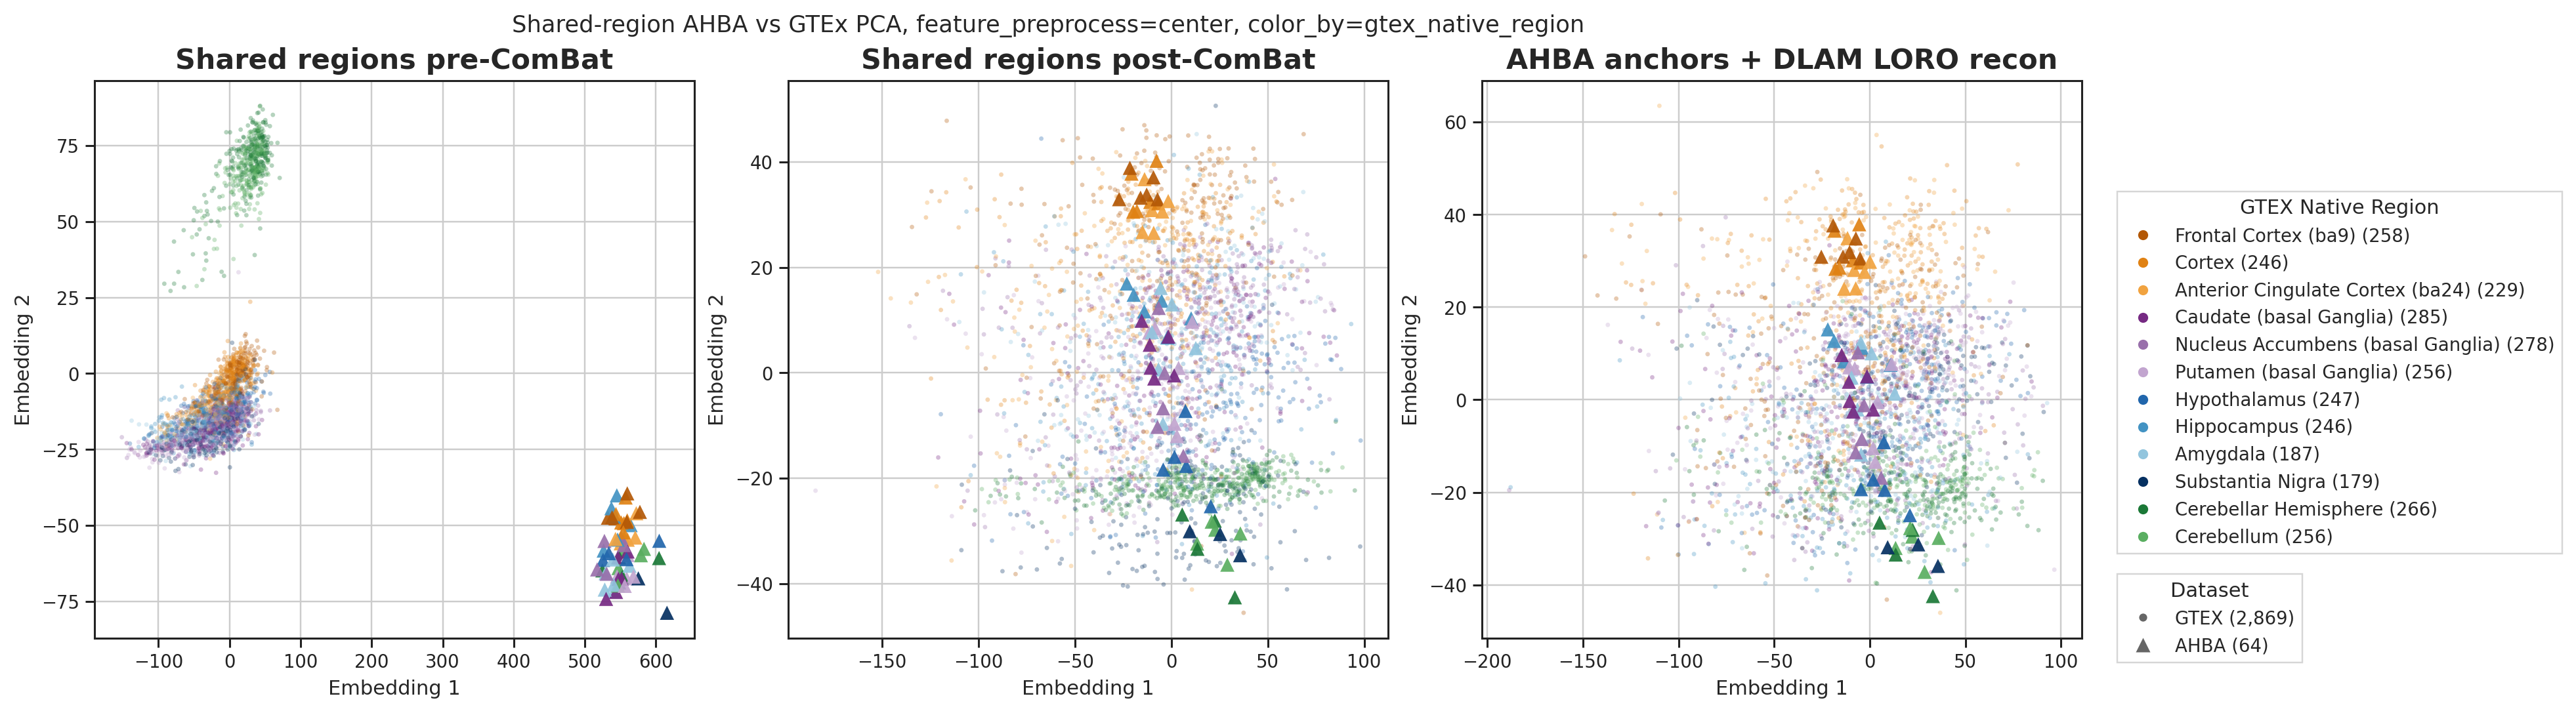

/ext3/miniforge3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/ext3/miniforge3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/ext3/miniforge3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


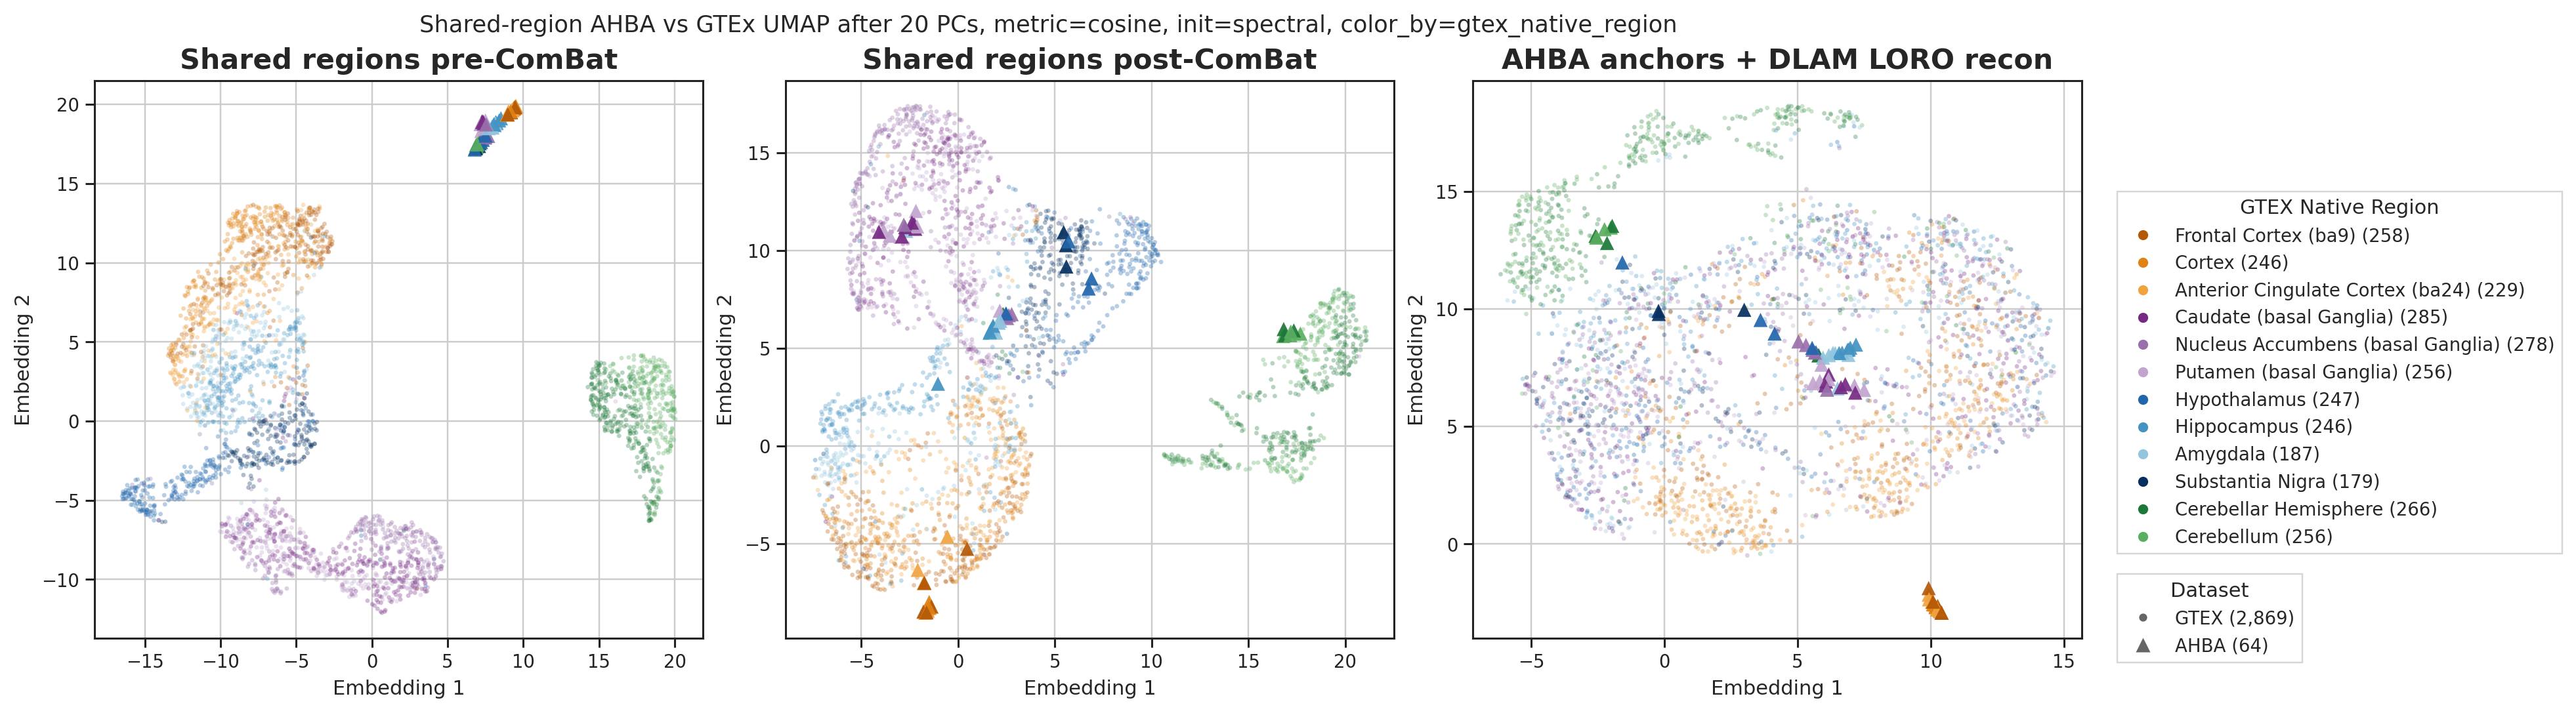

In [38]:
shared_raw = _joint_matrix(
    _combat_view("GTEx", "raw_matched", "region_matched"),
    _combat_view("AHBA", "raw_matched", "region_matched"),
)
shared_harm = _joint_matrix(
    _combat_view("GTEx", "harmonized", "region_matched"),
    _combat_view("AHBA", "harmonized", "region_matched"),
)
shared_loro_recon = _joint_matrix(
    _prediction_view("loro_recon", "region_matched"),
    _combat_view("AHBA", "harmonized", "region_matched"),
)

SHARED_MATRICES = [shared_raw, shared_harm, shared_loro_recon]
SHARED_TITLES = [
    "Shared regions pre-ComBat",
    "Shared regions post-ComBat",
    f"AHBA anchors + {LORO_MODEL.upper()} LORO recon",
]
_print_matrix_summary(SHARED_TITLES, SHARED_MATRICES)

_plot_embedding_sequence(
    SHARED_MATRICES,
    SHARED_TITLES,
    color_by=SHARED_COLOR_BY,
    base_title="Shared-region AHBA vs GTEx",
)


## AHBA Superset And Fused PCA


In [ ]:
# PCA controls for this section only.
SUPERSET_FUSED_PCA_RUN_PCA = True
SUPERSET_FUSED_PCA_RUN_UMAP = False
SUPERSET_FUSED_PCA_COLOR_BY = SUPERSET_PCA_COLOR_BY

# Marker controls for this section only.
SUPERSET_FUSED_PCA_MARKERS = {"GTEx": "o", "AHBA": "^"}
SUPERSET_FUSED_PCA_POINT_SIZES = {"GTEx": 5, "AHBA": 50}
SUPERSET_FUSED_PCA_ALPHAS = {"GTEx": 0.32, "AHBA": 0.92}


AHBA superset pre-ComBat: 3,422 rows x 11,704 genes; rows_by_dataset={'GTEx': 2869, 'AHBA': 553}; dropped=0
AHBA superset post-ComBat: 3,422 rows x 11,704 genes; rows_by_dataset={'GTEx': 2869, 'AHBA': 553}; dropped=0
AHBA reference + DLAM LORO fused: 48,253 rows x 11,704 genes; rows_by_dataset={'GTEx': 47700, 'AHBA': 553}; dropped=0


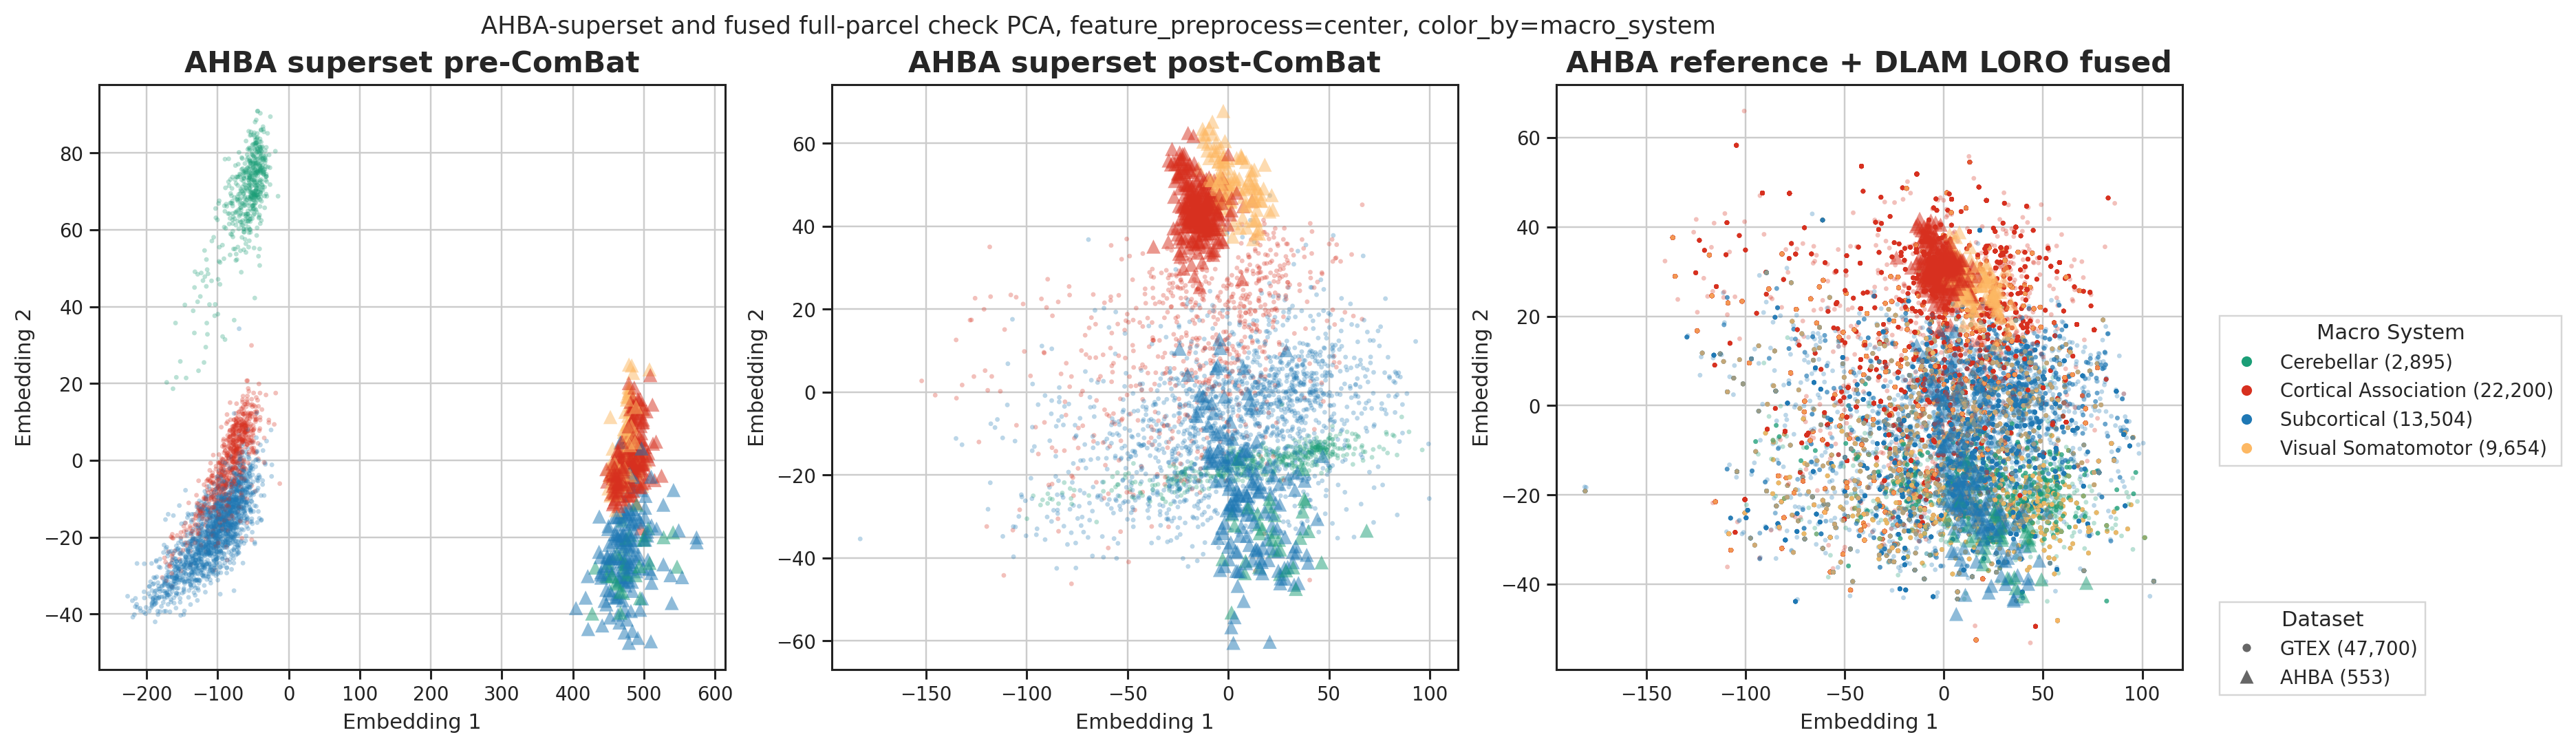

In [50]:
superset_raw = _joint_matrix(
    _combat_view("GTEx", "raw_matched", "region_matched_superset"),
    _combat_view("AHBA", "raw_matched", "region_matched_superset"),
)
superset_harm = _joint_matrix(
    _combat_view("GTEx", "harmonized", "region_matched_superset"),
    _combat_view("AHBA", "harmonized", "region_matched_superset"),
)
fused_full = _joint_matrix(
    _prediction_view("loro_fused", "target_parcel"),
    _combat_view("AHBA", "harmonized", "target_parcel"),
)

SUPERSET_FUSED_PCA_MATRICES = [superset_raw, superset_harm, fused_full]
SUPERSET_FUSED_PCA_TITLES = [
    "AHBA superset pre-ComBat",
    "AHBA superset post-ComBat",
    f"AHBA reference + {LORO_MODEL.upper()} LORO fused",
]
_print_matrix_summary(SUPERSET_FUSED_PCA_TITLES, SUPERSET_FUSED_PCA_MATRICES)

_plot_embedding_sequence(
    SUPERSET_FUSED_PCA_MATRICES,
    SUPERSET_FUSED_PCA_TITLES,
    color_by=SUPERSET_FUSED_PCA_COLOR_BY,
    base_title="AHBA-superset and fused full-parcel check",
    run_pca=SUPERSET_FUSED_PCA_RUN_PCA,
    run_umap=SUPERSET_FUSED_PCA_RUN_UMAP,
    dataset_markers=SUPERSET_FUSED_PCA_MARKERS,
    dataset_point_sizes=SUPERSET_FUSED_PCA_POINT_SIZES,
    dataset_alphas=SUPERSET_FUSED_PCA_ALPHAS,
)


## Standalone LORO Fused UMAP


In [ ]:
# Fused view UMAP controls. Dense fused predictions can have many near-duplicate
# extrapolated rows; random init avoids repeated spectral eigengap warnings.
FUSED_RUN_UMAP = True
FUSED_N_PCA_FOR_UMAP = 20
FUSED_UMAP_N_NEIGHBORS = 30
FUSED_UMAP_MIN_DIST = 0.8
FUSED_UMAP_SPREAD = 1.8
FUSED_UMAP_REPULSION = 1.25
FUSED_UMAP_METRIC = "cosine"
FUSED_UMAP_INIT = "random"
FUSED_UMAP_COLOR_BY = FUSED_COLOR_BY
# Set to None to allow UMAP parallelism and suppress the n_jobs/random_state warning.
FUSED_UMAP_RANDOM_STATE = RANDOM_STATE

# Balance only the standalone fused UMAP. Default for fresh notebooks keeps the full point set.
BALANCE_FUSED_POINTS = False
BALANCE_RANDOM_STATE = 0

# Marker controls for this standalone UMAP only.
FUSED_DATASET_MARKERS = DATASET_MARKERS
FUSED_DATASET_POINT_SIZES = DATASET_POINT_SIZES
FUSED_DATASET_ALPHAS = DATASET_ALPHAS


AHBA reference + DLAM LORO fused: 1,106 rows x 11,704 genes; rows_by_dataset={'GTEx': 553, 'AHBA': 553}; dropped=47147


/ext3/miniforge3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


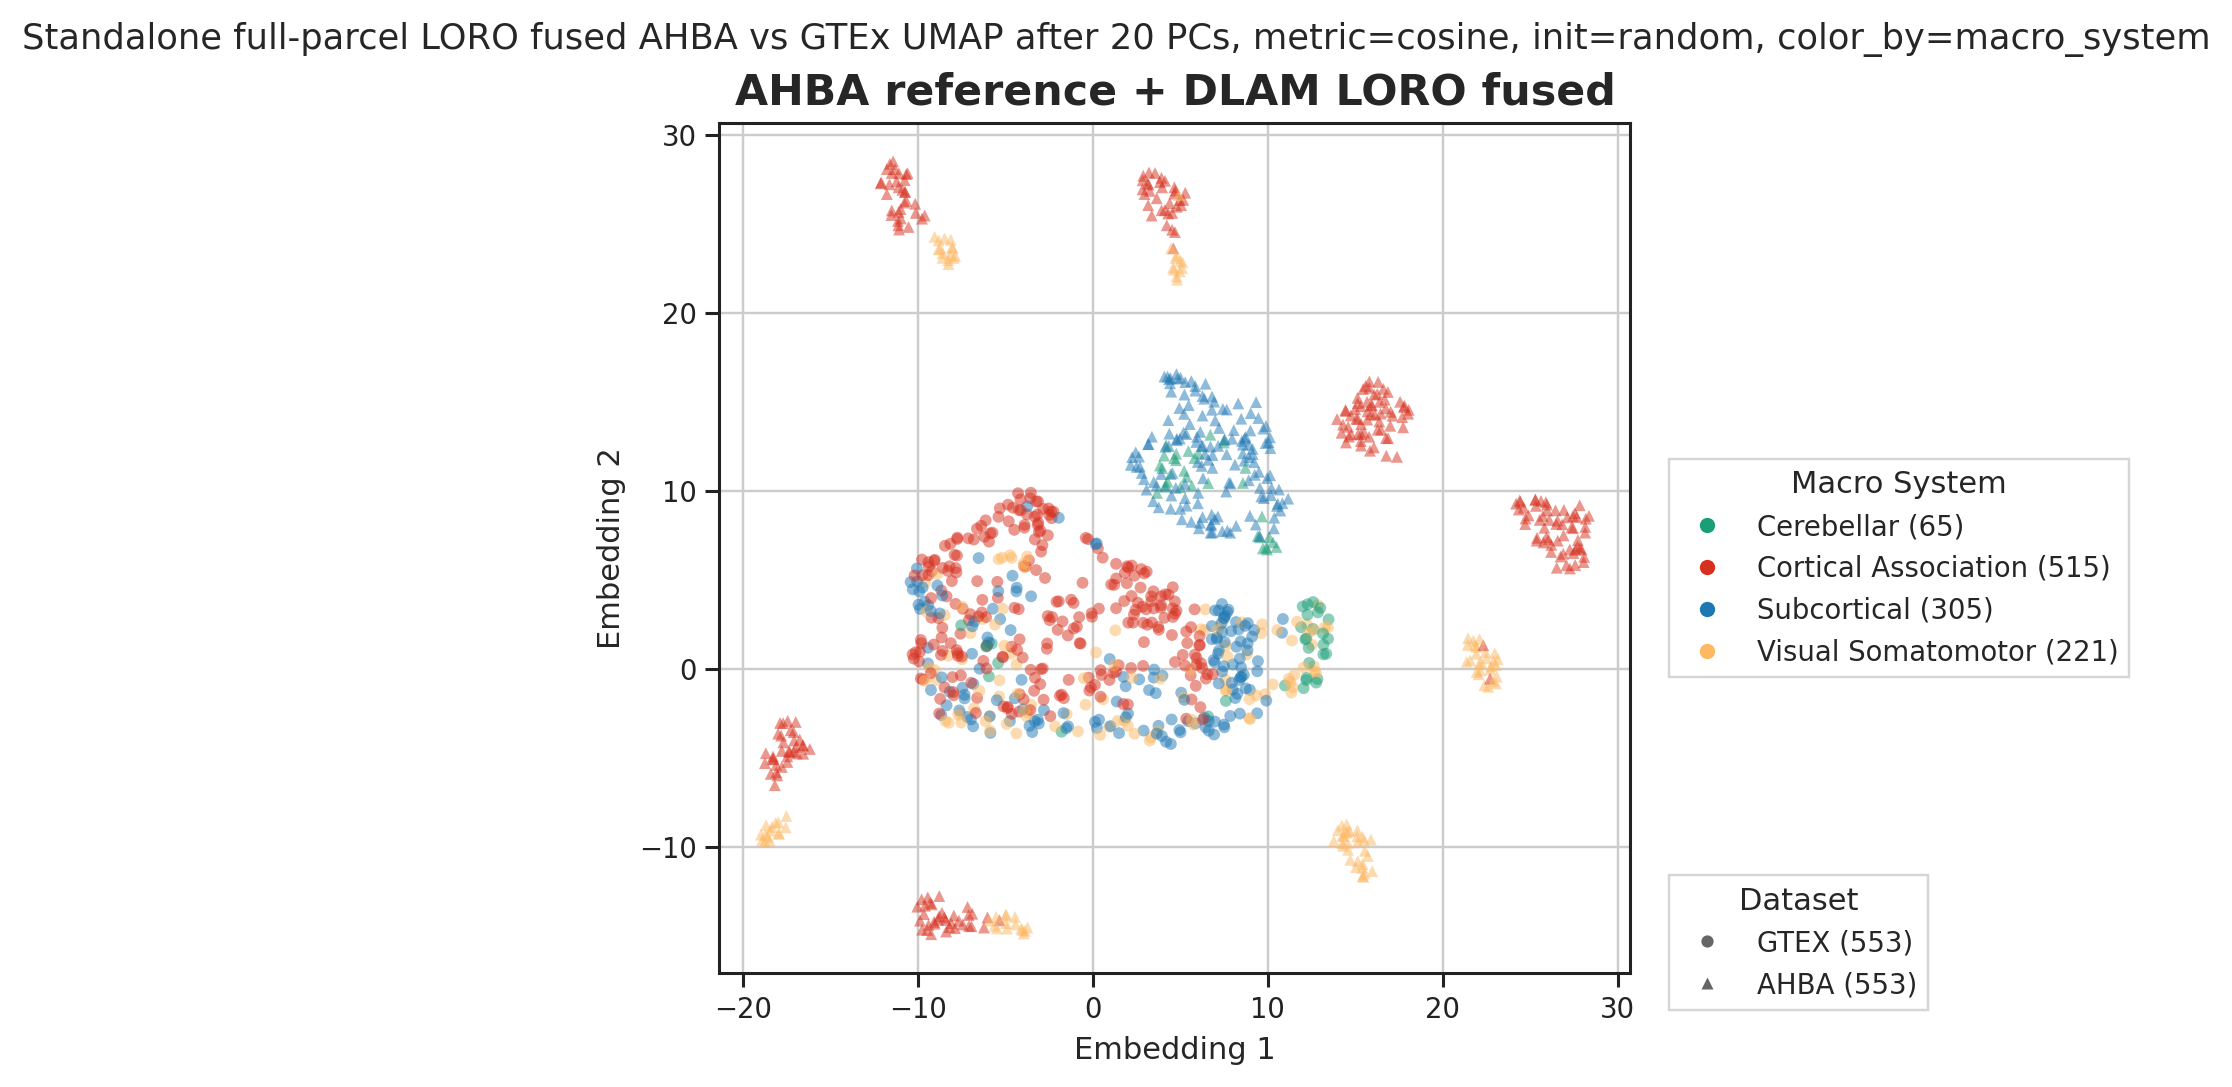

In [42]:
fused_umap_matrix = _balance_matrix_by_dataset(
    fused_full,
    enabled=BALANCE_FUSED_POINTS,
    random_state=BALANCE_RANDOM_STATE,
)

FUSED_UMAP_MATRICES = [fused_umap_matrix]
FUSED_UMAP_TITLES = [f"AHBA reference + {LORO_MODEL.upper()} LORO fused"]
_print_matrix_summary(FUSED_UMAP_TITLES, FUSED_UMAP_MATRICES)

_plot_embedding_sequence(
    FUSED_UMAP_MATRICES,
    FUSED_UMAP_TITLES,
    color_by=FUSED_UMAP_COLOR_BY,
    base_title="Standalone full-parcel LORO fused AHBA vs GTEx",
    run_pca=False,
    run_umap=FUSED_RUN_UMAP,
    dataset_markers=FUSED_DATASET_MARKERS,
    dataset_point_sizes=FUSED_DATASET_POINT_SIZES,
    dataset_alphas=FUSED_DATASET_ALPHAS,
    umap_params={
        "n_pca": FUSED_N_PCA_FOR_UMAP,
        "n_neighbors": FUSED_UMAP_N_NEIGHBORS,
        "min_dist": FUSED_UMAP_MIN_DIST,
        "metric": FUSED_UMAP_METRIC,
        "spread": FUSED_UMAP_SPREAD,
        "repulsion": FUSED_UMAP_REPULSION,
        "init": FUSED_UMAP_INIT,
        "random_state": FUSED_UMAP_RANDOM_STATE,
    },
)
